In [42]:
posts_path =r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\processed\processed_posts_df.csv"
comments_path = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\processed\processed_comments_df.csv"

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import emoji
import nltk
import numpy as np
from prefixspan import PrefixSpan


In [44]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [45]:
post_df = pd.read_csv(posts_path)
comment_df = pd.read_csv(comments_path)

In [46]:
post_df.head()

,post_id,postUser,timestamp,likesCount,commentsCount,keywords_posts
0,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"['cannes', 'kilian', 'dress', '2023', 'kilianp..."
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,6565,86,"['2022', '2023', 'clock', 'struck', 'midnight'..."
2,3,maryleest,2023-05-29 18:57:51+00:00,28936,123,"['dress', 'jewelry', 'famous', 'stairs', 'phot..."
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,4764,215,"['show', 'chanel', 'fashion', 'shoes', 'visual..."
4,5,maryleest,2023-05-23 21:11:12+00:00,13379,123,"['cannes', 'cannesfilmfestival', 'festival', '..."


In [47]:
comment_df.head()

,post_id,commentUser,timestamp,likes,clean_comment,tokens,polarity,sentiment,tfidf_keywords
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,0.0,i have a proposal for u send me a dm please,"['proposal', 'u', 'send', 'dm', 'please']",0.2074,neutral,"['dm', 'please', 'amazing', 'beautiful', 'blac..."
1,1,mariavmh,2023-06-04 16:46:40+00:00,0.0,woaaaah,['woaaaah'],-0.5351,negative,"['amazing', 'beautiful', 'black_heart', 'blue_..."
2,1,mariavmh,2023-06-04 16:46:34+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"['smiling_face_with_heart', 'eyes', 'smiling_f...",0.8857,positive,"['smiling_face_with_heart', 'eyes', 'amazing',..."
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,0.0,red_heart red_heart red_heart,"['red_heart', 'red_heart', 'red_heart']",0.2744,neutral,"['red_heart', 'amazing', 'beautiful', 'black_h..."
4,1,jillviv,2023-06-04 15:06:03+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"['smiling_face_with_heart', 'eyes', 'smiling_f...",0.9791,positive,"['smiling_face_with_heart', 'eyes', 'amazing',..."


In [48]:
import pandas as pd
import ast

comment_df['tokens'] = comment_df['tokens'].apply(ast.literal_eval)
comment_df['tfidf_keywords'] = comment_df['tfidf_keywords'].apply(ast.literal_eval)
post_df['keywords_posts'] = post_df['keywords_posts'].apply(ast.literal_eval)

In [49]:
merged_df = pd.merge(comment_df, post_df[['post_id', 'keywords_posts']], on='post_id', how='left')

merged_df['combined_keywords'] = merged_df.apply(
    lambda row: row['tokens'] + row['keywords_posts'], axis=1
)

In [50]:
merged_df['joined_sequence'] = merged_df['combined_keywords'].apply(lambda x: ' '.join(x))

In [51]:
merged_df.head()

,post_id,commentUser,timestamp,likes,clean_comment,tokens,polarity,sentiment,tfidf_keywords,keywords_posts,combined_keywords,joined_sequence
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,0.0,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.2074,neutral,"[dm, please, amazing, beautiful, black_heart]","[cannes, kilian, dress, 2023, kilianparis, kil...","[proposal, u, send, dm, please, cannes, kilian...",proposal u send dm please cannes kilian dress ...
1,1,mariavmh,2023-06-04 16:46:40+00:00,0.0,woaaaah,[woaaaah],-0.5351,negative,"[amazing, beautiful, black_heart, blue_heart, ...","[cannes, kilian, dress, 2023, kilianparis, kil...","[woaaaah, cannes, kilian, dress, 2023, kilianp...",woaaaah cannes kilian dress 2023 kilianparis k...
2,1,mariavmh,2023-06-04 16:46:34+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w...",0.8857,positive,"[smiling_face_with_heart, eyes, amazing, beaut...","[cannes, kilian, dress, 2023, kilianparis, kil...","[smiling_face_with_heart, eyes, smiling_face_w...",smiling_face_with_heart eyes smiling_face_with...
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,0.0,red_heart red_heart red_heart,"[red_heart, red_heart, red_heart]",0.2744,neutral,"[red_heart, amazing, beautiful, black_heart, b...","[cannes, kilian, dress, 2023, kilianparis, kil...","[red_heart, red_heart, red_heart, cannes, kili...",red_heart red_heart red_heart cannes kilian dr...
4,1,jillviv,2023-06-04 15:06:03+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w...",0.9791,positive,"[smiling_face_with_heart, eyes, amazing, beaut...","[cannes, kilian, dress, 2023, kilianparis, kil...","[smiling_face_with_heart, eyes, smiling_face_w...",smiling_face_with_heart eyes smiling_face_with...


In [ ]:
comment_agg = comment_df.groupby('post_id')['comments'].apply(list).reset_index()
merged_df = post_df.merge(comment_agg, on='post_id', how='left')

In [6]:
df = merged_df.drop(columns=['image'])
df.rename(columns={'ownerUsername': 'postUser'}, inplace=True)
df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount,comments
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142,"[I have a proposal for u, send me a DM please!..."
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",NaN,6565,86,[Hey Tina I just want to make sure you got my ...
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo @gustave_durin Dre...,NaN,28936,123,"[love this monochrome look :fire::fire::fire:,..."
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,CHANELFallWinter,4764,215,[:OK_hand_medium_skin_tone::white_heart::smili...
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123,"[Маша, ты королева :broken_heart:, :heart_on_f..."


In [7]:
print ("Rows : " ,df.shape[0])
print ("Columns : " ,df.shape[1])
print ("\nFeatures : \n" ,df.columns.tolist())

Rows :  827
Columns :  8

Features : 
 ['post_id', 'timestamp', 'postUser', 'caption', 'hashtags', 'likesCount', 'commentsCount', 'comments']


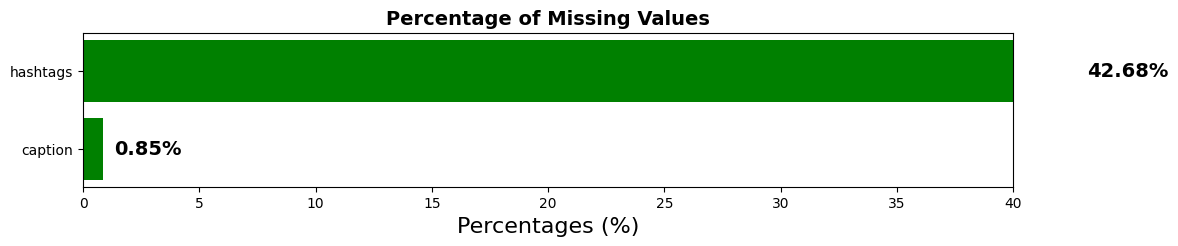

In [8]:
# Calculating the percentage of missing values for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

# Prepare values
missing_percentage.sort_values(ascending=True, inplace=True)

# Plot the barh chart
fig, ax = plt.subplots(figsize=(12, 2))
ax.barh(missing_percentage.index, missing_percentage, color='green')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=14, color='black')

# Set x-axis limit
ax.set_xlim([0, 40])

# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=14)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

In [9]:
# Fill missing value in caption and hashtags column by ""
df['caption'] = df['caption'].fillna('')
df['hashtags'] = df['hashtags'].fillna('')

In [10]:
df.isnull().sum()

post_id          0
timestamp        0
postUser         0
caption          0
hashtags         0
likesCount       0
commentsCount    0
comments         0
dtype: int64

In [11]:
# Type of each column
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.dtypes   

post_id                        int64
timestamp        datetime64[ns, UTC]
postUser                      object
caption                       object
hashtags                      object
likesCount                     int64
commentsCount                  int64
comments                      object
dtype: object

### "Caption" Column

In [12]:
# Clean caption
def clean_caption(text):
    if pd.isna(text) or text == '':
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^\w\s\U0001F000-\U0001F9FF]', ' ', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['clean_caption'] = df['caption'].apply(clean_caption)

In [13]:
# Process Emoji in caption
import emoji

def process_emoji(text):
    emojis_list = [c for c in text if c in emoji.EMOJI_DATA]
    
    emoji_descriptions = []
    for e in emojis_list:
        emoji_name = emoji.demojize(e).replace(':', '').replace('_', '   ')
        emoji_descriptions.append(emoji_name)
    
    text_without_emoji = ''.join(c for c in text if c not in emoji.EMOJI_DATA)
    
    return text_without_emoji, emoji_descriptions

df[['caption_no_emoji', 'emoji_descriptions']] = df['clean_caption'].apply(lambda x: pd.Series(process_emoji(x)))


### "Hashtag" column

In [14]:
# Process hashtags from hashtag column
def process_hashtags_from_column(hashtag_text):
    if pd.isna(hashtag_text) or hashtag_text == 'nan' or hashtag_text == '':
        return []
    
    if hashtag_text.startswith('[') and hashtag_text.endswith(']'):
        hashtag_text = hashtag_text[1:-1]
        
        tags = [tag.strip().strip("'").strip('"') for tag in hashtag_text.split(',')]
    else:
        tags = [tag.strip().strip('#') for tag in re.split(r'[,#]', hashtag_text) if tag.strip()]
    
    processed_hashtags = []
    for tag in tags:
        if tag:
            words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', tag)
            if not words:
                words = [tag]
            processed_hashtags.extend([word.lower() for word in words])
    
    return processed_hashtags

df['hashtags'] = df['hashtags'].apply(process_hashtags_from_column)

In [16]:
# Tokenize and remove stopwords
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def tokenize_and_remove_stopwords(text):
    
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]
    
    return filtered_tokens

df['caption_tokens'] = df['caption_no_emoji'].apply(tokenize_and_remove_stopwords)

In [17]:
df['combined_tokens'] = df.apply(lambda row: row['caption_tokens'] + row['emoji_descriptions'] + row['hashtags'], axis=1)

In [19]:
df_processed = df[['post_id', 'postUser', 'combined_tokens']]
df_processed.head(5)

,post_id,postUser,combined_tokens
0,1,maryleest,"[cannes, 2023, kilianparis, kiliancannes, wear..."
1,2,tinaabeysekara,"[clock, struck, midnight, ring, 2022, cried, w..."
2,3,maryleest,"[famous, stairs, photo, gustave_durin, dress, ..."
3,4,stephaniebroek,"[visualized, moment, many, times, first, chane..."
4,5,maryleest,"[got, witness, historical, moment, cinema, kil..."


### BERT Embedding for combined_tokens

In [20]:
from transformers import BertTokenizer, BertModel
import torch

# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [21]:
def get_bert_embedding(tokens):
    """Convert combined_tokens (list of words) to a BERT embedding."""
    text = " ".join(tokens)  # Convert list to a single sentence
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=50)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()  # Take mean embedding

# Apply to dataframe
df_processed['bert_embedding'] = df_processed['combined_tokens'].apply(get_bert_embedding)

print(df_processed[['combined_tokens', 'bert_embedding']].head())

                                     combined_tokens  \
0  [cannes, 2023, kilianparis, kiliancannes, wear...   
1  [clock, struck, midnight, ring, 2022, cried, w...   
2  [famous, stairs, photo, gustave_durin, dress, ...   
3  [visualized, moment, many, times, first, chane...   
4  [got, witness, historical, moment, cinema, kil...   

                                      bert_embedding  
0  [-0.057473496, -0.37669498, 0.2771262, 0.08630...  
1  [0.15091066, -0.07945559, 0.801254, -0.2211145...  
2  [0.043599136, 0.1377868, 0.1308463, -0.2802139...  
3  [-0.12334566, -0.1385878, 0.6960119, -0.126099...  
4  [0.24099723, 0.202147, 0.1673808, 0.0060400893...  


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6280\3521289661.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_processed['bert_embedding'] = df_processed['combined_tokens'].apply(get_bert_embedding)


### Handle OOV Words with Word2Vec

In [22]:
from gensim.models import Word2Vec

# Train Word2Vec on combined_tokens
w2v_model = Word2Vec(df['combined_tokens'], vector_size=100, window=5, min_count=1, workers=4)

def get_w2v_embedding(tokens):
    """Average Word2Vec vectors for a sentence."""
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)  # Handle OOV cases

df_processed['word2vec_embedding'] = df_processed['combined_tokens'].apply(get_w2v_embedding)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6280\1223182056.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_processed['word2vec_embedding'] = df_processed['combined_tokens'].apply(get_w2v_embedding)


#### Combine BERT & Word2Vec:

In [23]:
def combine_embeddings(bert_vec, w2v_vec):
    """Combine BERT and Word2Vec embeddings, using Word2Vec when BERT fails."""
    if np.all(bert_vec == 0):  # Nếu BERT không có vector (OOV case)
        return w2v_vec
    return np.concatenate([bert_vec, w2v_vec])  # Kết hợp cả hai

df_processed['final_embedding'] = df_processed.apply(lambda row: combine_embeddings(row['bert_embedding'], row['word2vec_embedding']), axis=1)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6280\1641342415.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_processed['final_embedding'] = df_processed.apply(lambda row: combine_embeddings(row['bert_embedding'], row['word2vec_embedding']), axis=1)


In [24]:
fashion_keywords = {
    # 👕 Clothing Items
    "clothing_items": [
        "sweater", "blouse", "jeans", "t-shirt", "shirt", "dress", "skirt", "trousers", 
        "shorts", "cardigan", "hoodie", "jumpsuit", "romper", "suit", "blazer", "coat",
        "jacket", "overcoat", "windbreaker", "leggings", "crop top", "tank top", "bodysuit"
    ],
    
    # 🧵 Materials
    "materials": [
        "cotton", "linen", "denim", "silk", "wool", "polyester", "rayon", "spandex",
        "leather", "suede", "cashmere", "velvet", "satin", "chiffon", "mesh", "lace",
        "knit", "corduroy", "tweed", "nylon", "faux fur", "hemp", "modal", "terrycloth"
    ],
    
    # 🎨 Colors
    "colors": [
        "black", "white", "navy", "beige", "cream", "khaki", "gray", "charcoal", "brown",
        "olive", "mustard", "gold", "silver", "bronze", "teal", "turquoise", "aqua",
        "red", "maroon", "burgundy", "pink", "rose", "peach", "coral", "orange",
        "yellow", "lime", "green", "mint", "forest green", "blue", "royal blue",
        "indigo", "purple", "lavender", "violet", "lilac"
    ],
    
    # 🏷️ Styles
    "styles": [
        "vintage", "bohemian", "minimalist", "streetwear", "casual", "business casual",
        "formal", "elegant", "chic", "grunge", "punk", "gothic", "preppy", "hipster",
        "y2k", "athleisure", "skater", "retro", "avant-garde", "monochrome", "artsy",
        "country", "military", "workwear", "sporty", "kawaii", "coquette"
    ],
    
    # 🛍️ Brands (Luxury & High-Street)
    "brands": [
        "Gucci", "Zara", "Uniqlo", "Prada", "Louis Vuitton", "Chanel", "Hermès", "Dior",
        "Balenciaga", "Versace", "Burberry", "Givenchy", "Dolce & Gabbana", "Fendi",
        "Saint Laurent", "Alexander McQueen", "Tom Ford", "Celine", "Valentino",
        "Armani", "Ralph Lauren", "Lacoste", "Hugo Boss", "Calvin Klein", "Levi's",
        "Nike", "Adidas", "Puma", "New Balance", "Under Armour", "Reebok", "The North Face",
        "Patagonia", "H&M", "Mango", "ASOS", "Bershka", "Forever 21", "Urban Outfitters",
        "Shein", "Victoria’s Secret"
    ],

    # 🖼️ Patterns
    "patterns": [
        "striped", "polka dot", "floral", "paisley", "plaid", "herringbone", "tie-dye",
        "leopard print", "zebra print", "camouflage", "geometric", "tartan", "abstract",
        "checkered", "ombre", "holographic", "baroque"
    ],

    # 👜 Accessories
    "accessories": [
        "hat", "cap", "beanie", "scarf", "belt", "gloves", "earrings", "necklace",
        "bracelet", "rings", "watch", "handbag", "tote bag", "clutch", "backpack",
        "sunglasses", "eyeglasses", "hairband", "headband", "shawl"
    ],

    # 👟 Footwear
    "footwear": [
        "sneakers", "heels", "boots", "sandals", "loafers", "oxfords", "moccasins",
        "flip-flops", "espadrilles", "wedges", "slippers", "platform shoes", "ballet flats"
    ]
}


In [25]:
import torch.nn as nn

class AttentionLayer(nn.Module):
    """Simple Attention Mechanism"""
    def __init__(self, input_dim):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Linear(input_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attention(x), dim=1)  # Compute attention weights
        return (weights * x).sum(dim=1)  # Weighted sum

# Tính trọng số Attention dựa trên fashion keywords
def get_attention_weights(tokens):
    return [1.5 if token in fashion_keywords else 1.0 for token in tokens]

# Apply attention
df_processed['attention_weights'] = df_processed['combined_tokens'].apply(get_attention_weights)
attention_layer = AttentionLayer(len(df_processed['final_embedding'][0]))  # Kích thước embedding

# Convert embeddings to tensor
embeddings_tensor = torch.tensor(df_processed['final_embedding'].tolist(), dtype=torch.float32)
attention_output = attention_layer(embeddings_tensor)

df_processed['final_fashion_embedding'] = attention_output.tolist()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6280\4274515284.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_processed['attention_weights'] = df_processed['combined_tokens'].apply(get_attention_weights)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6280\4274515284.py:22: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  embeddings_tensor = torch.tensor(df_processed['final_embedding'].tolist(), dtype=torch.float32)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6280\4274515284.py

In [26]:
df_processed.head()

,post_id,postUser,combined_tokens,bert_embedding,word2vec_embedding,final_embedding,attention_weights,final_fashion_embedding
0,1,maryleest,"[cannes, 2023, kilianparis, kiliancannes, wear...","[-0.057473496, -0.37669498, 0.2771262, 0.08630...","[-0.0056489157, 0.0068669645, 0.0018501675, 0....","[-0.057473496, -0.37669498, 0.2771262, 0.08630...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",-7.322248
1,2,tinaabeysekara,"[clock, struck, midnight, ring, 2022, cried, w...","[0.15091066, -0.07945559, 0.801254, -0.2211145...","[-0.001990675, 0.0030883846, 0.0011387077, -7....","[0.15091066, -0.07945559, 0.801254, -0.2211145...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",-8.395658
2,3,maryleest,"[famous, stairs, photo, gustave_durin, dress, ...","[0.043599136, 0.1377868, 0.1308463, -0.2802139...","[-0.0028900865, 0.0022133798, -0.0016326403, 0...","[0.043599136, 0.1377868, 0.1308463, -0.2802139...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",-7.746532
3,4,stephaniebroek,"[visualized, moment, many, times, first, chane...","[-0.12334566, -0.1385878, 0.6960119, -0.126099...","[-0.0039418098, 0.0040515866, 0.0007322031, -0...","[-0.12334566, -0.1385878, 0.6960119, -0.126099...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",-7.681353
4,5,maryleest,"[got, witness, historical, moment, cinema, kil...","[0.24099723, 0.202147, 0.1673808, 0.0060400893...","[-0.00056999084, 0.0038623982, -0.0010221662, ...","[0.24099723, 0.202147, 0.1673808, 0.0060400893...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",-10.291544
